# Telco Churn — Exploratory Data Analysis

> This notebook documents the data exploration that informed
> feature engineering and model pipeline decisions in `scripts/`.
> Last updated after correlation analysis pass.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='coolwarm')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Dataset shape: 7043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Types and the mistyped column

In [2]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

**Note — mistyped column:** `TotalCharges` is loaded as `object` (text), even
though it should be numeric. The cause is empty strings (`' '`) on rows where
`tenure == 0` (brand-new customers who have not been billed yet). `SeniorCitizen`
is stored as `int` but is really a 0/1 categorical flag.

In [3]:
# Confirm the implicit-missing trap
blank = df['TotalCharges'].astype(str).str.strip() == ''
print(f"Blank TotalCharges rows: {blank.sum()}")
df.loc[blank, ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

Blank TotalCharges rows: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


## 2. Missing values (explicit NaN + implicit empties)

In [4]:
explicit = df.isnull().sum()
print('Explicit NaN per column:')
print(explicit[explicit > 0] if explicit.any() else 'None')

tc_numeric = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"\nImplicit empties in TotalCharges (become NaN after coercion): {tc_numeric.isnull().sum()}")

Explicit NaN per column:
None

Implicit empties in TotalCharges (become NaN after coercion): 11


## 3. Target distribution (class imbalance)

Churn rate: 26.5%  |  majority-class accuracy baseline: 73.5%


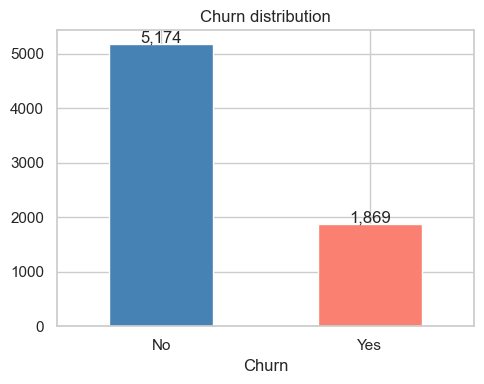

In [5]:
churn_rate = (df['Churn'] == 'Yes').mean()
print(f'Churn rate: {churn_rate:.1%}  |  majority-class accuracy baseline: {1 - churn_rate:.1%}')

fig, ax = plt.subplots(figsize=(5, 4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], ax=ax)
ax.set_title('Churn distribution')
ax.set_xticklabels(['No', 'Yes'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + 0.15, p.get_height() + 40))
plt.tight_layout(); plt.show()

## 4. Numeric distributions

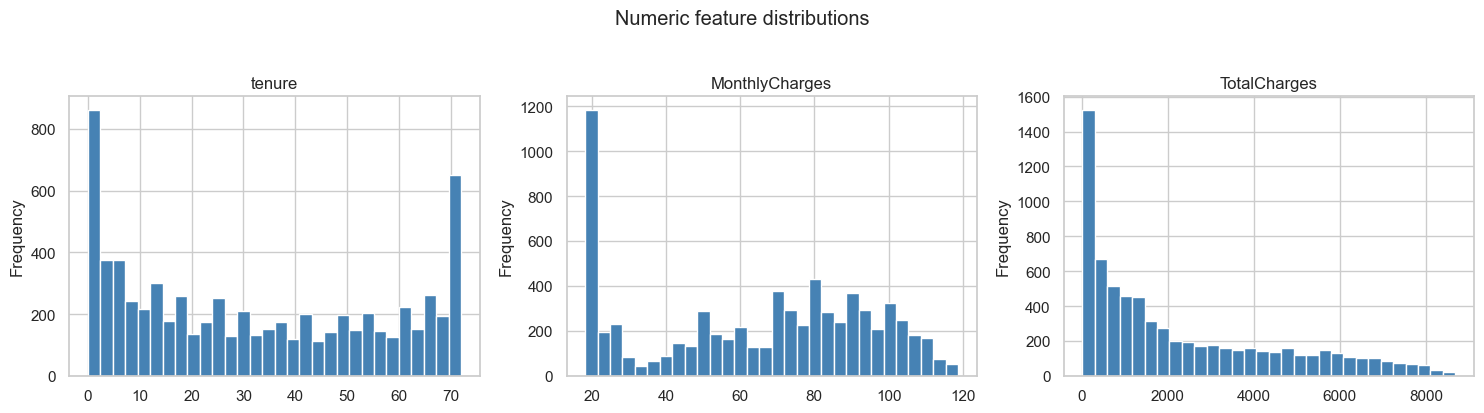

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    df[col].plot(kind='hist', bins=30, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col)
plt.suptitle('Numeric feature distributions', y=1.03)
plt.tight_layout(); plt.show()

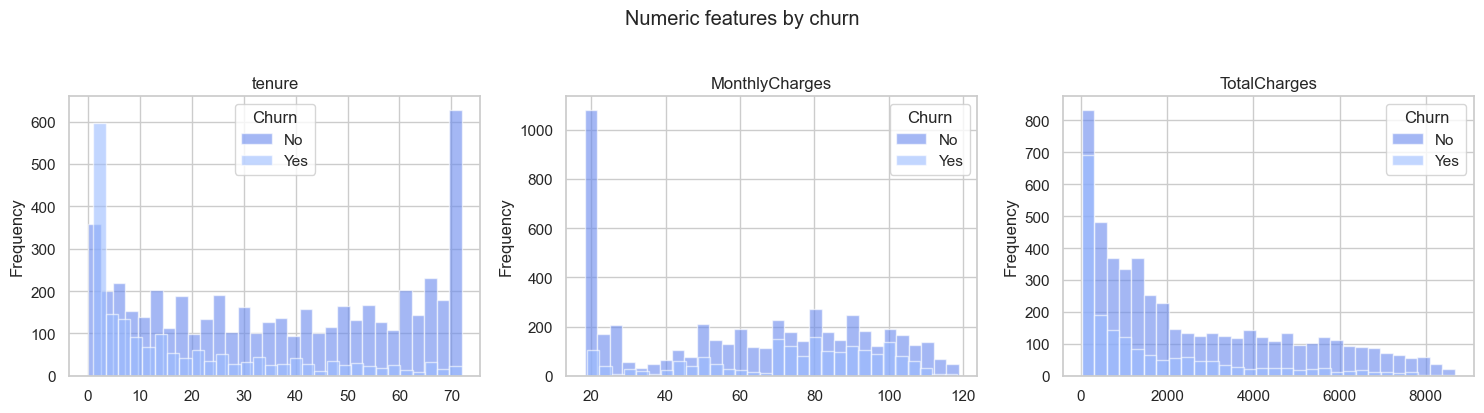

In [7]:
# Numeric features split by churn — tenure separates the classes strongly
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    for label, grp in df.groupby('Churn'):
        grp[col].plot(kind='hist', bins=30, alpha=0.6, ax=ax, label=label)
    ax.set_title(col); ax.legend(title='Churn')
plt.suptitle('Numeric features by churn', y=1.03)
plt.tight_layout(); plt.show()

## 5. Churn by categorical features (cross-tabulation)

In [8]:
for col in ['Contract', 'PaymentMethod', 'InternetService']:
    ct = pd.crosstab(df[col], df['Churn'], normalize='index')
    print(f'=== Churn rate by {col} ===')
    print((ct['Yes'] * 100).round(1).astype(str) + '%')
    print()

=== Churn rate by Contract ===
Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%
Name: Yes, dtype: str

=== Churn rate by PaymentMethod ===
PaymentMethod
Bank transfer (automatic)    16.7%
Credit card (automatic)      15.2%
Electronic check             45.3%
Mailed check                 19.1%
Name: Yes, dtype: str

=== Churn rate by InternetService ===
InternetService
DSL            19.0%
Fiber optic    41.9%
No              7.4%
Name: Yes, dtype: str



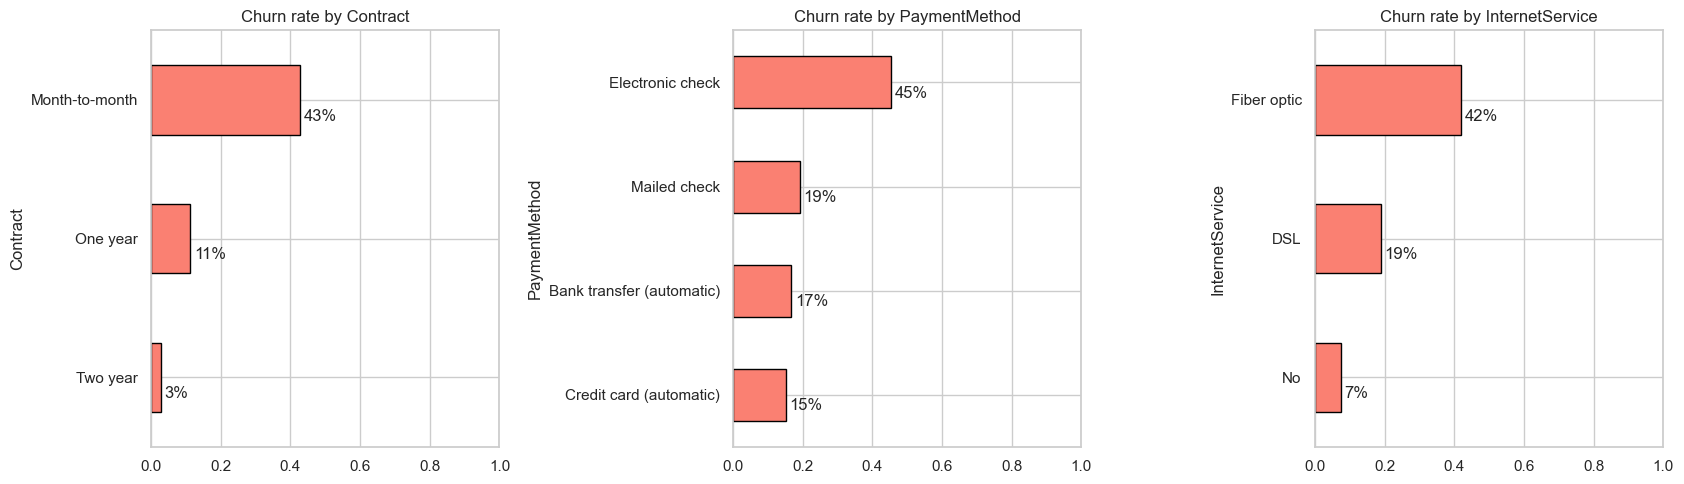

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, col in zip(axes, ['Contract', 'PaymentMethod', 'InternetService']):
    rate = df.assign(churn=(df['Churn'] == 'Yes')).groupby(col)['churn'].mean().sort_values()
    rate.plot(kind='barh', ax=ax, color='salmon', edgecolor='black')
    ax.set_title(f'Churn rate by {col}'); ax.set_xlim(0, 1)
    for p in ax.patches:
        ax.annotate(f'{p.get_width():.0%}', (p.get_width() + 0.01, p.get_y() + 0.1))
plt.tight_layout(); plt.show()

## 6. Insights

1. **Contract is the dominant churn driver.** Month-to-month customers churn at
   ~43%, versus ~3% for two-year contracts — a >10x gap. This motivates keeping
   `Contract` and engineering a coarse `tenure_bucket`.
2. **New customers leave fast.** The churn-vs-tenure histogram shows churners
   concentrated at low tenure; long-tenured customers almost never churn.
3. **Fiber-optic internet and electronic-check payment correlate with high
   churn**, while customers with more add-on services (security, support,
   backup) churn less — which is why we engineer an `n_services` count.
4. **The class imbalance (~27% churn) makes accuracy useless**: predicting
   "no churn" for everyone already scores 73.5%. We optimise recall instead.
5. **TotalCharges is nearly collinear with tenure** (Pearson r ≈ 0.83);
   one of the two should be dropped or the pair should be replaced by
   `MonthlyCharges` alone to avoid redundancy in linear models.


## 7. Correlation among numeric features

Quick correlation check to ensure no multicollinearity issues before modelling.


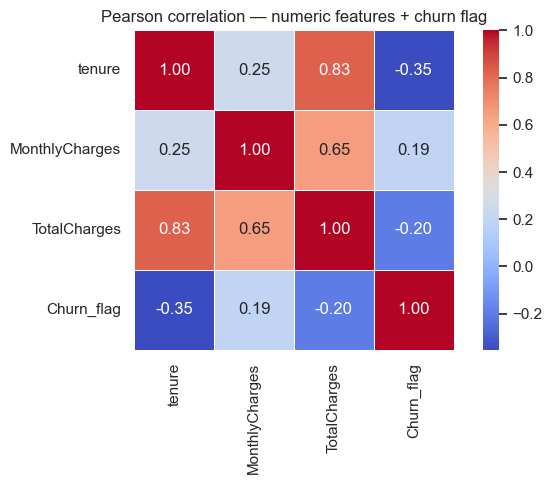


Key finding: TotalCharges ~ tenure (r=0.83) — expected, since total = monthly × months.
Churn correlates negatively with tenure: longer customers stay.


In [10]:
# Encode binary churn for correlation
df_corr = df.copy()
df_corr['TotalCharges'] = pd.to_numeric(df_corr['TotalCharges'], errors='coerce')
df_corr['Churn_flag'] = (df_corr['Churn'] == 'Yes').astype(int)

corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_flag']
corr_matrix = df_corr[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Pearson correlation — numeric features + churn flag')
plt.tight_layout()
plt.show()

print('\nKey finding: TotalCharges ~ tenure (r=0.83) — expected, since total = monthly × months.')
print('Churn correlates negatively with tenure: longer customers stay.')